In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from z_calculator import vapour_compress as z_calc

In [2]:

data = pd.DataFrame(columns=["p", "T", "d", "d_top", "n"])
for i in range(1, 31):
    with open(f"welltests//W{i}_welltest.txt") as f:
        lines = f.readlines()
        T = float(lines[6][-9:][1:8])
        p = float(lines[5][-9:][1:8])
    
    log_i = np.loadtxt(f"welllogs//W{i}_welllogs.txt", skiprows=4)
    d = log_i[-1, 0] - log_i[0, 0]
    d_top = log_i[0, 0]
    n = np.mean(log_i[:, 1])
    
    data.loc[i-1] = [p, T, d, d_top, n]

data.head()

,p,T,d,d_top,n
0,190.657,339.194,82.15,1807.00,0.161835
1,204.845,341.336,126.02,1922.14,0.189198
2,198.011,342.076,107.07,1953.64,0.163787
3,210.697,346.547,181.79,2102.64,0.183000
4,211.411,341.225,122.67,1917.34,0.177893


         p        T       d    d_top         n       Z_1       Z_2       Z_3
0  190.657  339.194   82.15  1807.00  0.161835  0.557363  1.129878  0.820866
1  204.845  341.336  126.02  1922.14  0.189198  0.582882  1.140191  0.835770
2  198.011  342.076  107.07  1953.64  0.163787  0.572278  1.134729  0.830726
3  210.697  346.547  181.79  2102.64  0.183000  0.596989  1.143152  0.847612
4  211.411  341.225  122.67  1917.34  0.177893  0.593897  1.145307  0.842029


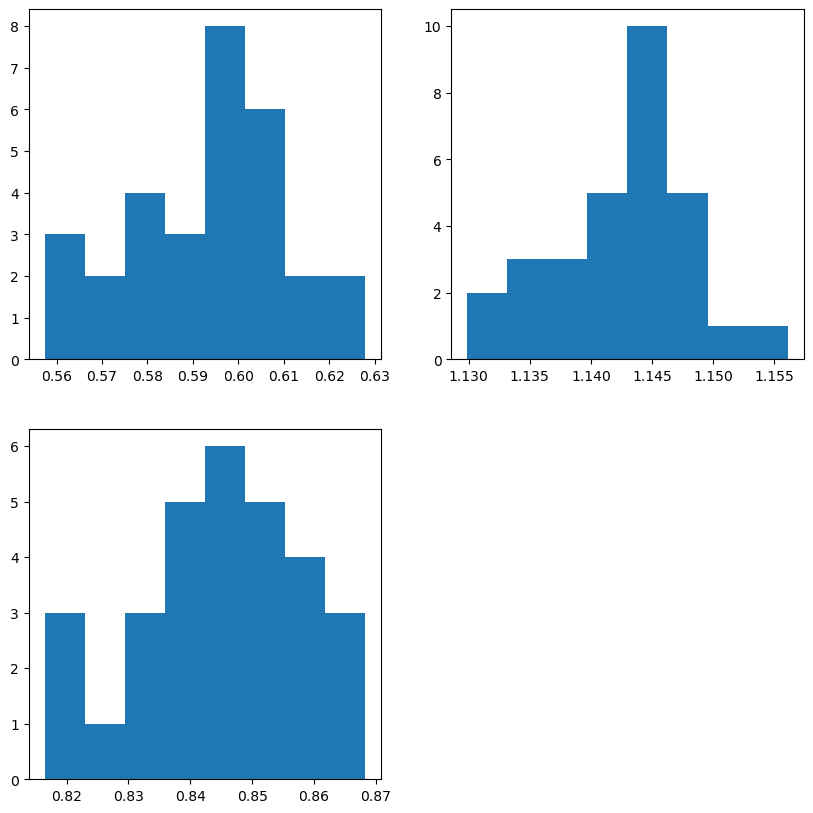

In [15]:
scenarios = [['CO2', 'N2'], ['H2', 'C1'], ['C1', 'C2', 'H2S']]
ratios = [[0.95, 0.05], [0.95, 0.05], [0.85, 0.10, 0.05]]

for i in range(len(scenarios)):
    
    z_i = []
    for j in range(len(data)):
        z_i.append(z_calc(data['p'][j], data['T'][j], ratios[i], scenarios[i])[0])

    data[f"Z_{i+1}"] = z_i
    
print(data.head())

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
ax4.set_visible(False)

ax1.hist(data['Z_1'], bins=8, density=False)
ax2.hist(data['Z_2'], bins=8, density=False)
ax3.hist(data['Z_3'], bins=8, density=False);